# Data Preprocessing

**Libraries and Data import**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [5]:
import kagglehub

path=kagglehub.dataset_download("yasserh/titanic-dataset")
print("Path to dataset files: ",path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files:  /kaggle/input/titanic-dataset


In [6]:
import os

print("\nFiles in dataset folder:")
print(os.listdir(path))

# Load Titanic CSV file
df = pd.read_csv(os.path.join(path, "Titanic-Dataset.csv"))

print("\nFirst 5 rows:")
display(df.head())


Files in dataset folder:
['Titanic-Dataset.csv']

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**EXPLORE BASIC INFORMATION**

In [7]:
print("\n========== BASIC INFORMATION ==========")

# Number of rows and columns
print("Shape of dataset:", df.shape)

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# Basic information
print("\nDataset information:")
df.info()

# Statistical summary
print("\nStatistical summary:")
display(df.describe())

# Number of missing values
print("\nMissing values:")
print(df.isnull().sum())

# Number of unique values
print("\nUnique values:")
print(df.nunique())


========== BASIC INFORMATION ==========
Shape of dataset: (891, 12)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null   

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Unique values:
PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64


**HANDLE MISSING VALUES**

In [8]:
print("\n========== HANDLING MISSING VALUES ==========")

# Check missing values before handling
print("Missing values before handling:")
print(df.isnull().sum())

# -----------------------------------
# Age: Fill missing values with median
# -----------------------------------
df['Age'] = df['Age'].fillna(df['Age'].median())

# -----------------------------------
# Embarked: Fill missing values with mode
# -----------------------------------
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# -----------------------------------
# Fare: Fill missing values with median
# -----------------------------------
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# -----------------------------------
# Cabin: Too many missing values
# Drop Cabin column
# -----------------------------------
df.drop('Cabin', axis=1, inplace=True)

# Check missing values after handling
print("\nMissing values after handling:")
print(df.isnull().sum())


========== HANDLING MISSING VALUES ==========
Missing values before handling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


**CONVERT CATEGORICAL FEATURES INTO NUMERICAL**

In [9]:
print("\n========== ENCODING CATEGORICAL FEATURES ==========")

# Check categorical columns
print("Categorical columns:")
print(df.select_dtypes(include=['object']).columns.tolist())

# -----------------------------------
# Encode Sex
# male = 1
# female = 0
# -----------------------------------
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# -----------------------------------
# One-hot encode Embarked
# -----------------------------------
df = pd.get_dummies(
    df,
    columns=['Embarked'],
    drop_first=True,
    dtype=int
)


========== ENCODING CATEGORICAL FEATURES ==========
Categorical columns:
['Name', 'Sex', 'Ticket', 'Embarked']


**Drop unnecessary text columns**

In [10]:
# Name is not useful for this basic preprocessing task
# Ticket is also categorical/high-cardinality
df.drop(['Name', 'Ticket'], axis=1, inplace=True)

print("\nDataset after encoding:")
display(df.head())

print("\nData types after encoding:")
print(df.dtypes)


Dataset after encoding:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,1,22.0,1,0,7.2500,0,1
1,2,1,1,0,38.0,1,0,71.2833,0,0
2,3,1,3,0,26.0,0,0,7.9250,0,1
3,4,1,1,0,35.0,1,0,53.1000,0,1
4,5,0,3,1,35.0,0,0,8.0500,0,1



Data types after encoding:
PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked_Q       int64
Embarked_S       int64
dtype: object


**NORMALIZE / STANDARDIZE NUMERICAL FEATURES**

In [11]:
print("\n========== FEATURE SCALING ==========")

# Select numerical columns
numerical_columns = [
    'Age',
    'SibSp',
    'Parch',
    'Fare'
]

print("Numerical columns to scale:")
print(numerical_columns)

# -----------------------------------
# Standardization using StandardScaler
# Mean = 0
# Standard deviation = 1
# -----------------------------------

scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(
    df[numerical_columns]
)

print("\nDataset after Standardization:")
display(df.head())

print("\nMean after standardization:")
print(df[numerical_columns].mean())

print("\nStandard deviation after standardization:")
print(df[numerical_columns].std())


========== FEATURE SCALING ==========
Numerical columns to scale:
['Age', 'SibSp', 'Parch', 'Fare']

Dataset after Standardization:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,1,-0.565736,0.432793,-0.473674,-0.502445,0,1
1,2,1,1,0,0.663861,0.432793,-0.473674,0.786845,0,0
2,3,1,3,0,-0.258337,-0.474545,-0.473674,-0.488854,0,1
3,4,1,1,0,0.433312,0.432793,-0.473674,0.420730,0,1
4,5,0,3,1,0.433312,-0.474545,-0.473674,-0.486337,0,1



Mean after standardization:
Age      2.272780e-16
SibSp    4.386066e-17
Parch    5.382900e-17
Fare     3.987333e-18
dtype: float64

Standard deviation after standardization:
Age      1.000562
SibSp    1.000562
Parch    1.000562
Fare     1.000562
dtype: float64


**VISUALIZE OUTLIERS USING BOXPLOTS**


========== OUTLIER VISUALIZATION ==========


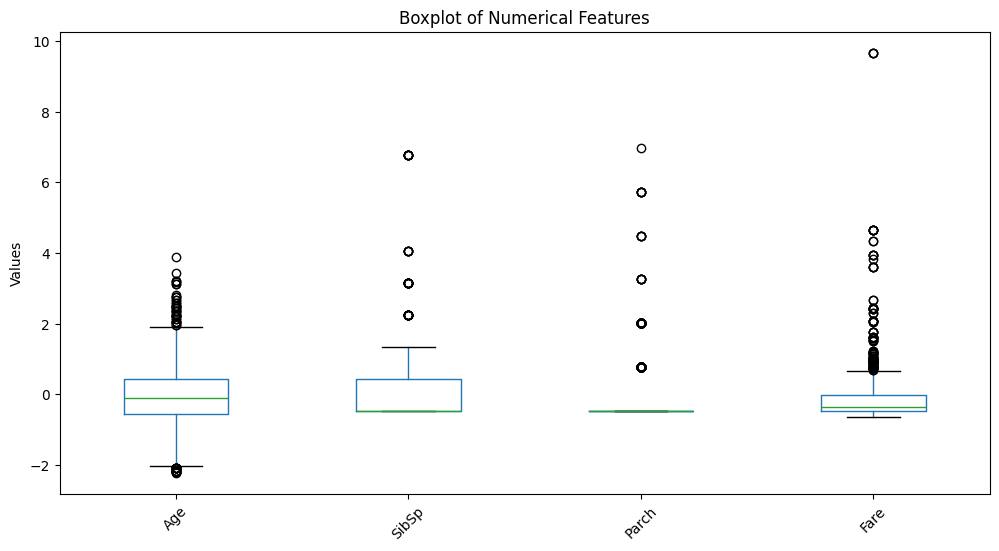

In [12]:
print("\n========== OUTLIER VISUALIZATION ==========")

# Create boxplots before removing outliers

plt.figure(figsize=(12, 6))

df[numerical_columns].boxplot()

plt.title("Boxplot of Numerical Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

**REMOVE OUTLIERS USING IQR METHOD**

In [13]:
print("\n========== REMOVING OUTLIERS ==========")

# Calculate Q1 and Q3
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

print("Q1:")
print(Q1)

print("\nQ3:")
print(Q3)

print("\nIQR:")
print(IQR)

# Define lower and upper limits
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nLower bounds:")
print(lower_bound)

print("\nUpper bounds:")
print(upper_bound)

# Create condition for rows without outliers
condition = ~(
    (df[numerical_columns] < lower_bound) |
    (df[numerical_columns] > upper_bound)
).any(axis=1)

# Remove outliers
df_clean = df[condition].copy()

print("\nOriginal dataset shape:", df.shape)
print("Dataset shape after removing outliers:", df_clean.shape)

print("\nNumber of rows removed:", df.shape[0] - df_clean.shape[0])



========== REMOVING OUTLIERS ==========
Q1:
Age     -0.565736
SibSp   -0.474545
Parch   -0.473674
Fare    -0.489148
Name: 0.25, dtype: float64

Q3:
Age      0.433312
SibSp    0.432793
Parch   -0.473674
Fare    -0.024246
Name: 0.75, dtype: float64

IQR:
Age      0.999048
SibSp    0.907339
Parch    0.000000
Fare     0.464902
dtype: float64

Lower bounds:
Age     -2.064308
SibSp   -1.835553
Parch   -0.473674
Fare    -1.186501
dtype: float64

Upper bounds:
Age      1.931883
SibSp    1.793801
Parch   -0.473674
Fare     0.673106
dtype: float64

Original dataset shape: (891, 10)
Dataset shape after removing outliers: (577, 10)

Number of rows removed: 314


**BOXPLOTS AFTER REMOVING OUTLIERS**

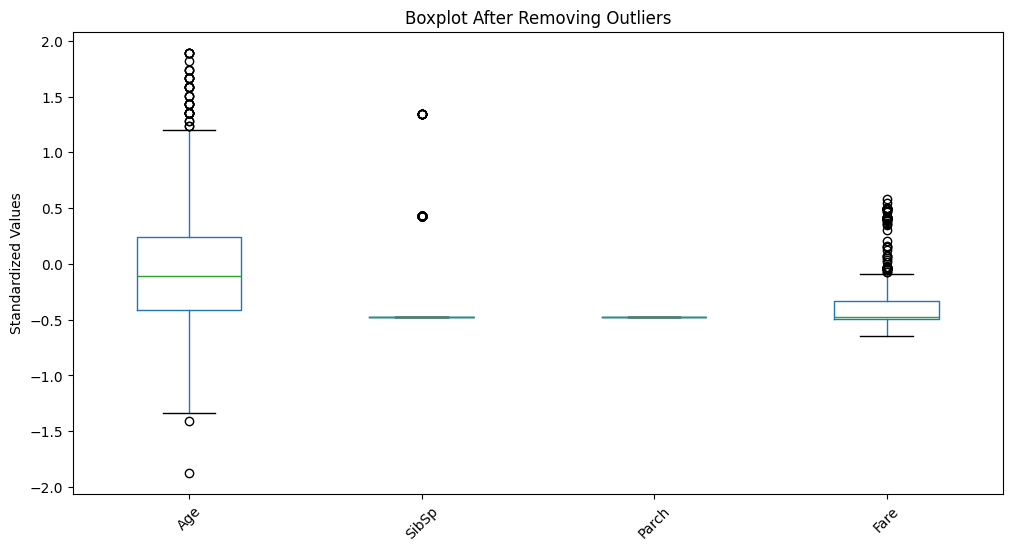

In [14]:
plt.figure(figsize=(12, 6))

df_clean[numerical_columns].boxplot()

plt.title("Boxplot After Removing Outliers")
plt.ylabel("Standardized Values")
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

**FINAL DATASET**

In [15]:
print("\n========== FINAL DATASET ==========")

print("Final shape:", df_clean.shape)

print("\nFinal data types:")
print(df_clean.dtypes)

print("\nFinal missing values:")
print(df_clean.isnull().sum())

print("\nFirst 10 rows of final dataset:")
display(df_clean.head(10))


========== FINAL DATASET ==========
Final shape: (577, 10)

Final data types:
PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp          float64
Parch          float64
Fare           float64
Embarked_Q       int64
Embarked_S       int64
dtype: object

Final missing values:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked_Q     0
Embarked_S     0
dtype: int64

First 10 rows of final dataset:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,1,-0.565736,0.432793,-0.473674,-0.502445,0,1
2,3,1,3,0,-0.258337,-0.474545,-0.473674,-0.488854,0,1
3,4,1,1,0,0.433312,0.432793,-0.473674,0.420730,0,1
4,5,0,3,1,0.433312,-0.474545,-0.473674,-0.486337,0,1
5,6,0,3,1,-0.104637,-0.474545,-0.473674,-0.478116,1,0
6,7,0,1,1,1.893459,-0.474545,-0.473674,0.395814,0,1
9,10,1,2,0,-1.180535,0.432793,-0.473674,-0.042956,0,0
12,13,0,3,1,-0.719436,-0.474545,-0.473674,-0.486337,0,1
14,15,0,3,0,-1.180535,-0.474545,-0.473674,-0.490280,0,1
17,18,1,2,1,-0.104637,-0.474545,-0.473674,-0.386671,0,1


**SAVE CLEAN DATASET**

In [16]:
df_clean.to_csv("Titanic_Cleaned.csv", index=False)

print("\nCleaned dataset saved as: Titanic_Cleaned.csv")


Cleaned dataset saved as: Titanic_Cleaned.csv
